# Case Study: Cyclistic Bike-Share Analysis
**Author:** Hanna Kovalenko

**Tools:** Python (Pandas, Matplotlib, Seaborn)

## 1. Phase: ASK
**Business Task:**
Cyclistic aims to increase the number of annual members, as they are more profitable than casual riders.
My objective is to analyze historical bike trip data to understand the differences in behavior between casual riders and annual members. These insights will help the marketing team design strategies to convert casual riders into loyal annual members.

**Key Question:**
* How do annual members and casual riders use Cyclistic bikes differently?
* Why would casual riders buy Cyclistic annual memberships?
* How can Cyclistic use digital media to influence casual riders to become members?

## 2. Phase: PREPARE
**Data Source:**
I am using the previous 12 months of Cyclistic trip data.
The data is stored in 12 separate CSV files.

### Data Credibility Check (ROCCC Analysis):
*   **Reliable:** The data is machine-generated by the bike tracking system, ensuring high accuracy and lack of bias. The sample size (approx. 5.5 million rides) is large enough to represent the population.
*   **Original:** This is first-party data provided directly by Motivate International Inc., the operator of the Cyclistic bike-share program.
*   **Comprehensive:** The dataset includes critical variables (start/end time, station names, user type). *Limitation:* Personal identifiable information (PII) such as age, gender, and credit card details has been removed for privacy protections. This prevents demographic analysis but allows for behavioral analysis.
*   **Current:** The data covers the most recent 12 months, reflecting up-to-date user behavior.
*   **Cited:** The data is public and available under a clear Data License Agreement.

**Steps taken:**
1. Loaded the necessary Python libraries.
2. Imported 12 CSV files.
3. Concatenated them into a single Dataframe.

In [1]:
# Import the nessesary Pathon librarues

import pandas as pd  
import numpy as np   
import matplotlib.pyplot as plt 
import seaborn as sns 
import glob 

In [2]:
# Import 12 CSV files

all_files = glob.glob("*.csv")

In [3]:
all_dataframes = []

for f in all_files:
    df = pd.read_csv(f)
    all_dataframes.append(df)
    print(f, 'added')

jul25.csv added
jan25.csv added
jun25.csv added
feb25.csv added
may25.csv added
dec24.csv added
nov24.csv added
okt25.csv added
apr25.csv added
mar25.csv added
sep25.csv added
aug25.csv added


In [4]:
# Concatenat them into a single Dataframe `df_all`

df_all = pd.concat(all_dataframes, ignore_index=True)
df_all.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member


In [5]:
df_all.dtypes

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

## 3. Phase: PROCESS
**Data Cleaning and Manipulation:**
Before analysis, the data needs to be cleaned and formatted.
1. **Date Formatting:** Converted `started_at` and `ended_at` columns to type datetime.
2. **Feature Engineering:**
   * Created a `ride_length` column to calculate trip duration.
   * Created a `day_of_week` column to analyze weekly patterns.
3. **Data Cleaning:**  Remove bad data (trips with negative or suspiciously short duration).
4. **Handling Missing Values.**

In [6]:
# Convert `started_at` and `ended_at` columns to type datetime
df_all['started_at'] = pd.to_datetime(df_all['started_at'])

df_all['ended_at'] = pd.to_datetime(df_all['ended_at'])

df_all.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object

In [12]:
# Created a `ride_duration` column (in minutes) and `day_of_week` column

df_all['ride_duration'] = (df_all['ended_at'] - df_all['started_at']).dt.total_seconds() / 60
df_all['weekday'] = df_all['started_at'].dt.day_name()
df_all.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,weekday
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member,10.643717,Saturday
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member,8.948367,Tuesday
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member,26.014283,Thursday
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member,10.560800,Thursday
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member,13.357900,Wednesday


In [14]:
# Check duplicates and ride duration statistics

print(f"Amount of duplicates: {df_all.duplicated().sum()}")

print("\nRide duration statistics (in minutes): ")
df_all['ride_duration'].describe()

Amount of duplicates: 0

Ride duration statistics (in minutes): 


count    5.569279e+06
mean     1.597048e+01
std      5.453003e+01
min     -5.602170e+01
25%      5.393883e+00
50%      9.419200e+00
75%      1.654402e+01
max      1.574900e+03
Name: ride_duration, dtype: float64

In [10]:
# How many trips are less than 1 minute (including negative ones)?

short_rides = df_all[df_all['ride_duration'] < 1].shape[0]
print("\nTrips that are less than 1 minute: ", short_rides)


Trips that are less than 1 minute:  142651


In [15]:
# Removе trips < 1 minute that are likely "false starts" or technical issues where users change the bike immediately

df_clean = df_all.copy()

df_clean = df_clean[df_clean['ride_duration'] > 1]
df_clean.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration,weekday
0,455D43BD91D73437,classic_bike,2025-07-05 17:15:08.456,2025-07-05 17:25:47.079,Lincoln Ave & Diversey Pkwy,CHI00285,Lincoln Ave & Addison St,CHI00478,41.932225,-87.658617,41.946176,-87.673308,member,10.643717,Saturday
1,9D4A6B723ECD98CA,classic_bike,2025-07-01 13:57:38.878,2025-07-01 14:06:35.780,Cottage Grove Ave & Oakwood Blvd,CHI00400,Cottage Grove Ave & 47th St,CHI00488,41.822985,-87.607100,41.809855,-87.606755,member,8.948367,Tuesday
2,C57044CF523302ED,classic_bike,2025-07-31 16:49:28.142,2025-07-31 17:15:28.999,Theater on the Lake,CHI00420,Winthrop Ave & Lawrence Ave,CHI00391,41.926277,-87.630834,41.968812,-87.657659,member,26.014283,Thursday
3,AFD35552E6685B6E,electric_bike,2025-07-17 09:36:21.058,2025-07-17 09:46:54.706,Pine Grove Ave & Waveland Ave,CHI00354,Winthrop Ave & Lawrence Ave,CHI00391,41.949473,-87.646453,41.968812,-87.657659,member,10.560800,Thursday
4,C0582EBAA6CED519,classic_bike,2025-07-02 18:43:45.213,2025-07-02 18:57:06.687,Theater on the Lake,CHI00420,Sheffield Ave & Wellington Ave,CHI00274,41.926277,-87.630834,41.936253,-87.652662,member,13.357900,Wednesday


In [16]:
# Check missing values

df_clean.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1081395
start_station_id      1081395
end_station_name      1111919
end_station_id        1111919
start_lat                   0
start_lng                   0
end_lat                  5460
end_lng                  5460
member_casual               0
ride_duration               0
weekday                     0
dtype: int64

Observed significant missing values in `start_station_name` and `end_station_name`.

 **Decision:** Keep these rows in order not to bias the analysis of ride duration and frequency.

## 4. Phase: ANALYZE
**Goal:** Determine how annual members and casual riders use bikes differently.

**Analysis Steps:**
1.  **Aggregated Data:** Grouped data by `member_casual` and `day_of_week`.
2.  **Calculated Metrics:**
    *   Average `ride_duration`.
    *   Total number of rides by day of week and by month (frequency).
3.  **Analyzed Bike Preference:** Checked if users prefer electric or classic bikes.


In [18]:
# Find Average ride duration

user_types = df_clean.groupby('member_casual')['ride_duration'].mean()

user_types

member_casual
casual    23.545186
member    12.436991
Name: ride_duration, dtype: float64

In [19]:
# Find total number of rides

user_types = df_clean.groupby('member_casual')['ride_duration'].count()
user_types

user_types

member_casual
casual    1926589
member    3500038
Name: ride_duration, dtype: int64

In [21]:
# Group data by `member_casual` and `day_of_week`

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_avg = df_clean.groupby(['weekday', 'member_casual'])['ride_duration'].mean().unstack()
day_avg = day_avg.reindex(order)

day_avg

member_casual,casual,member
weekday,,
Monday,23.160943,11.981102
Tuesday,20.551317,11.970076
Wednesday,19.555225,11.854056
Thursday,20.777280,12.041951
Friday,23.315183,12.372497
Saturday,26.439700,13.646042
Sunday,27.247976,13.796187


In [22]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_count = df_clean.groupby(['weekday', 'member_casual'])['ride_duration'].count().unstack()
day_count = day_count.reindex(order)

day_count

member_casual,casual,member
weekday,,
Monday,224604,504361
Tuesday,218285,555259
Wednesday,211859,534082
Thursday,246227,557382
Friday,308319,524475
Saturday,393946,440160
Sunday,323349,384319


In [23]:
df_clean['month'] = df_clean['started_at'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

month_count = df_clean.groupby(['month', 'member_casual'])['ride_id'].count().unstack()
month_count = month_count.reindex(month_order)
month_count


member_casual,casual,member
month,,
January,23453,112352
February,27051,122118
March,83064,208500
April,105528,257962
May,176162,314091
June,279570,379609
July,309293,430535
August,324165,443214
September,255223,441046


**Key Findings:**
*   **Ride Duration:** Casual riders take significantly longer trips (approx. 2x longer) than members.
*   **Weekly Pattern:**
    *   **Members:** Usage peaks on weekdays (Tue-Thu), suggesting commuting behavior. Drops on weekends.
    *   **Casuals:** Usage peaks on weekends and warm monthes suggesting leisure/tourist behavior.

## 5. Phase: SHARE
**Visualizations:**
I created data visualizations using `matplotlib` and `seaborn` to provide the findings.

1.  **Total Rides by Day of Week:** Visually demonstrates the "Commuter vs. Leisure" split.
2.  **Average Ride Duration:** Highlights the drastic difference in how long casuals keep the bikes compared to members.
3.  **Bike Type Preference:** Shows that electric bikes are popular across both user groups.

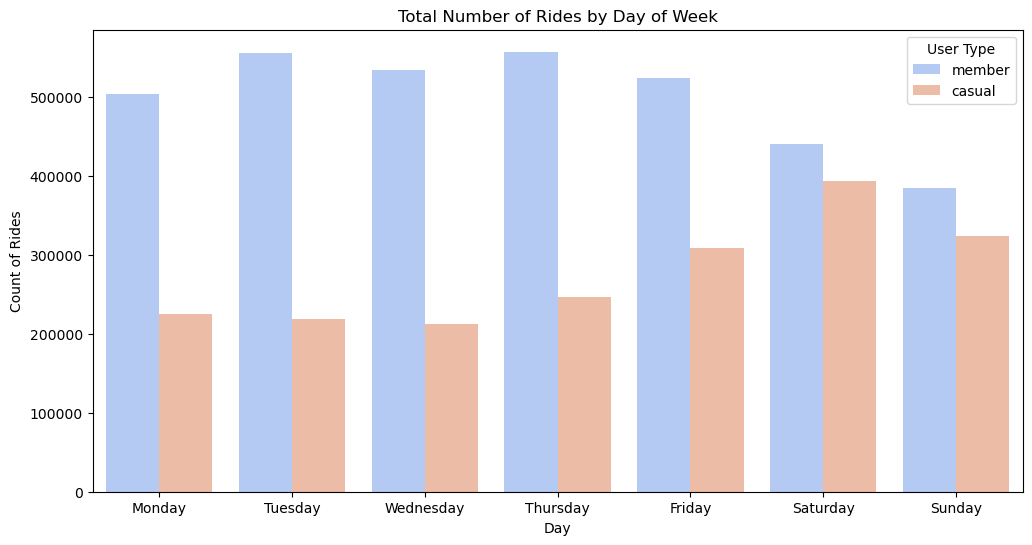

In [24]:
# Chart 1. Total Rides by day of week 

plt.figure(figsize=(12, 6))
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.countplot(data=df_clean, x='weekday', hue='member_casual', order=order_days, palette='coolwarm')

plt.title('Total Number of Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count of Rides')
plt.legend(title='User Type')
plt.show()

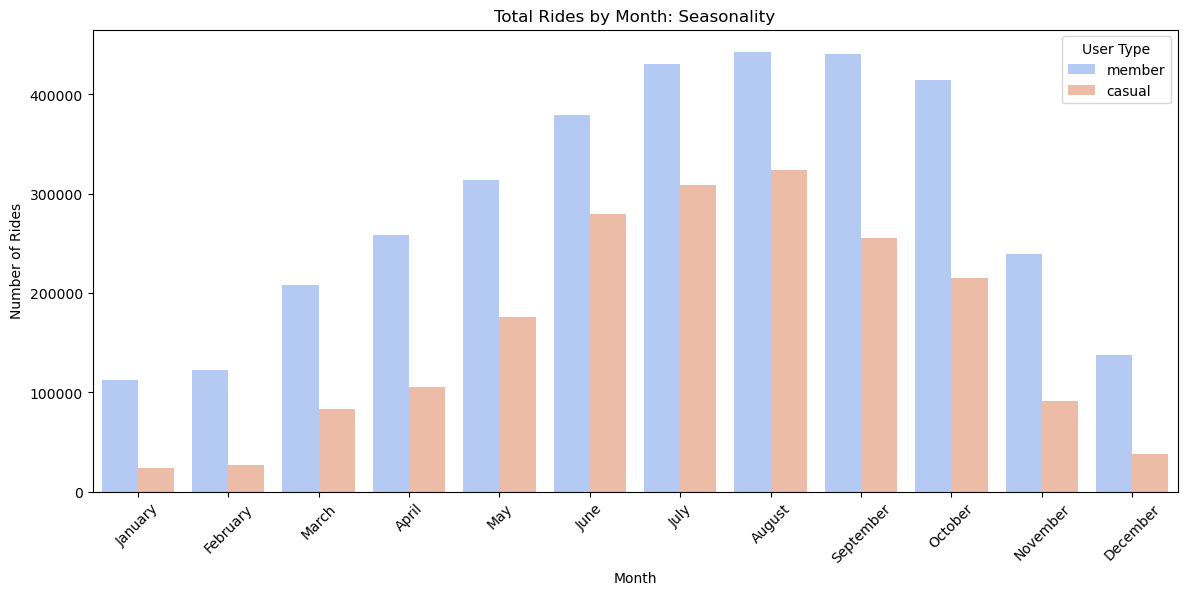

In [25]:
# Chart 2. Total Rides by month

plt.figure(figsize=(14, 6))

sns.countplot(data=df_clean, x='month', hue='member_casual', order=month_order, palette='coolwarm')

plt.title('Total Rides by Month: Seasonality')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='User Type')
plt.show()

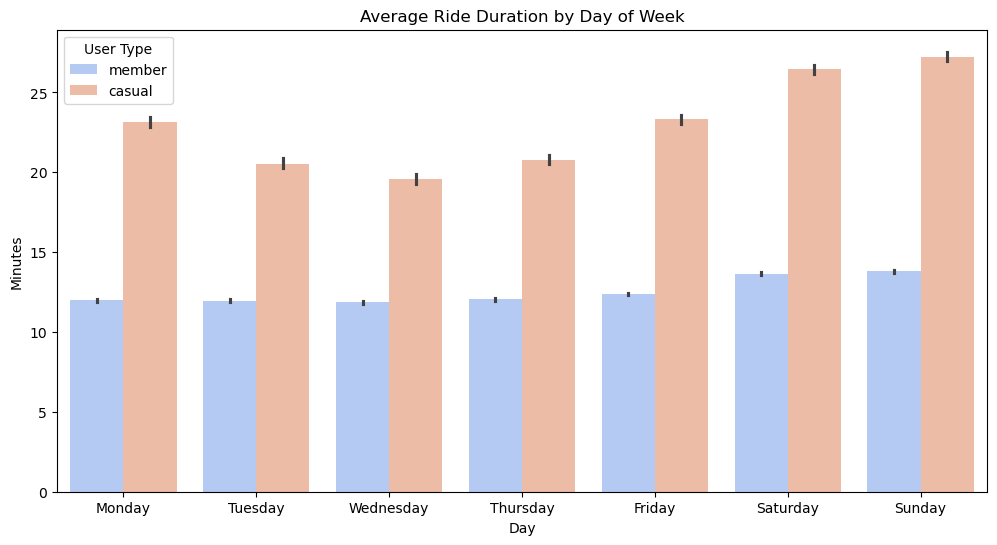

In [26]:
# Chart 3: Average Duration

plt.figure(figsize=(12, 6))
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(data=df_clean, x='weekday', y='ride_duration', hue='member_casual', order=order_days, palette='coolwarm')

plt.title('Average Ride Duration by Day of Week')
plt.xlabel('Day')
plt.ylabel('Minutes')
plt.legend(title='User Type')
plt.show()

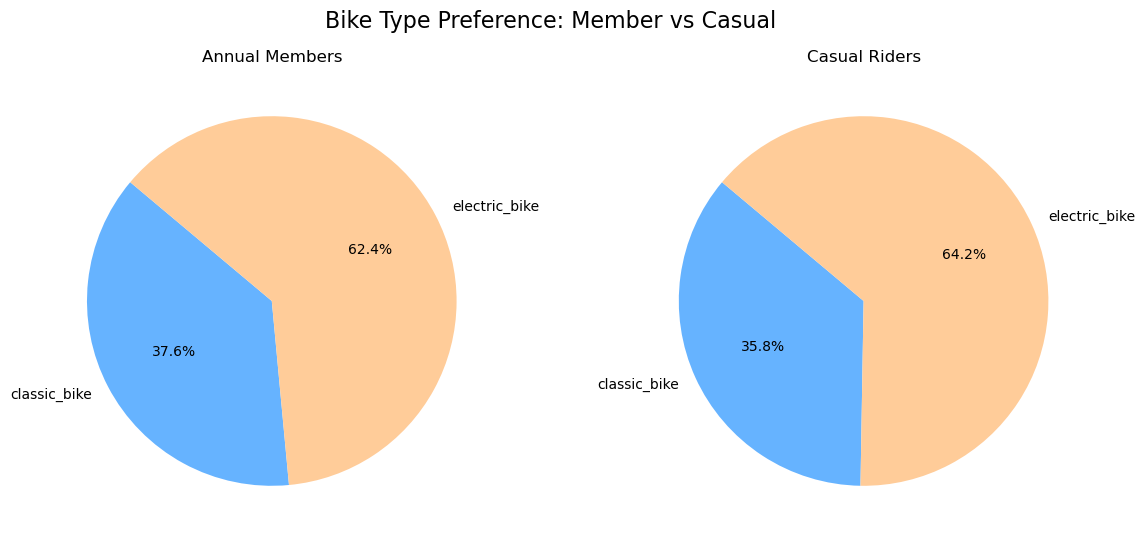

In [27]:
# Bike Type Preference

# Prapare data
bike_counts = df_clean.groupby(['member_casual', 'rideable_type']).size().reset_index(name='count')

member_data = bike_counts[bike_counts['member_casual'] == 'member']
casual_data = bike_counts[bike_counts['member_casual'] == 'casual']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Bike Type Preference: Member vs Casual', fontsize=16)

# Pie 1: MEMBERS 
axes[0].pie(
    member_data['count'], 
    labels=member_data['rideable_type'], 
    autopct='%1.1f%%',   
    startangle=140,      
    colors=['#66b3ff', '#ffcc99'] 
)
axes[0].set_title('Annual Members')

# Pie 2: CASUALS
axes[1].pie(
    casual_data['count'], 
    labels=casual_data['rideable_type'], 
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff','#ffcc99']
)
axes[1].set_title('Casual Riders')

plt.show()

## 6. Phase: ACT
**Conclusion:**
The data clearly shows two distinct user behaviors:
1.  **Annual Members** use Cyclistic bikes for **commuting** (short trips, weekdays).
2.  **Casual Riders** use Cyclistic bikes for **leisure** (long trips, weekends).

**Recommendations for Marketing Strategy:**

Based on the analysis, I propose the following strategies to convert casual riders into members:

1.  **Privide a "Leisure Membership":**
    *   *Insight:* Casual riders are most active on weekends.
    *   *Action:* Create a cheaper membership option valid only on Fridays, Saturdays, and Sundays. This targets the specific needs of leisure riders who don't need bikes for work commuting.

2.  **Promote "Unlimited Duration" for Members:**
    *   *Insight:* Casuals ride twice as long as members. They might hesitate to join if they fear time limits or overage fees.
    *   *Action:* Emphasize that membership provides extended travel time (or free unlocks), making it more economical for long rides.

3.  **Targeted Seasonal Campaigns:**
    *   *Insight:* Activity peaks in warmer months.
    *   *Action:* Launch heavy marketing campaigns in late Spring, focusing on the joy of summer riding and the convenience of electric bikes (which are popular with casuals).